
**Student Name:** Deepak Sindhu

**Student ID:** GH1056312

**Module:** M505 Introduction to AI and Machine Learning

**Github Repo** https://github.com/deepak324/python/tree/main/venv/bank_project


## 1. Introduction

    Digital marketing help banks to sell  term deposits. However, contacting customers without understanding their interests  increase costs. This project uses the Bank Marketing Dataset to develop a machine learning pipeline for predicting whether a customer will subscribe to a term deposit. The project includes data exploration, preprocessing, feature preparation, model training, hyperparameter tuning and evaluation.

## 2. Problem Definition

    **Problem Statement:**Banks used lot of resources on direct marketing campaigns that increase cost and reduce efficiency. Hence, observe customer responses before launching a campaign can improve decision-making and increase campaign success.

    **Machine Learning Problem:** This is a binary classification problem.

    **Objective/Motivation:** Accurate prediction helps banks to

    1. Reduce marketing costs
    2. Improve customer targeting
    3.  Increase campaign effectiveness
    4. Save employee time
    5. Improve customer satisfaction

 ## 3. Dataset Description:
    **Dataset Name:** Bank Marketing Dataset

    **Dataset Source** UCI Machine Learning Repository

    **Dataset Link:** https://archive.ics.uci.edu/ml/datasets/bank+marketing
    
    **Alternative OpenML Dataset:** https://www.openml.org/d/1461

    **License:** Public Research Dataset

    **Machine Learning Task:** Binary Classification

 ## 4. Exploratory Data Analysis
This section checks and then returns the dataset shape, feature types, missing values, target distribution, and descriptive statistics.

In [44]:


# data manipulation
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# import evaluation matrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)



In [45]:
df = pd.read_csv("bank-full.csv", sep=";")

print("dataset shape:", df.shape)
print("Column names:\n", df.columns.tolist())
print(df.info())
print("\nmissing values:")
print(df.isnull().sum())
print("\nDuplicate values:", df.duplicated().sum())
df.head()

dataset shape: (45211, 17)
Column names:
 ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   4

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


descriptive statistics:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%

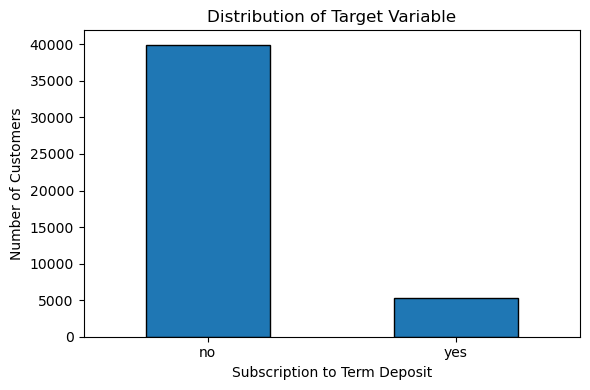

In [46]:
print("descriptive statistics:")
print(df.describe())
print("\nTarget variable distribution:")
print(df["y"].value_counts())
print("\nTarget variable percentages:")
print((df["y"].value_counts(normalize=True) * 100).round(2))

# target distribution graph
plt.figure(figsize=(6, 4))
df["y"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Distribution of Target Variable")
plt.xlabel("Subscription to Term Deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

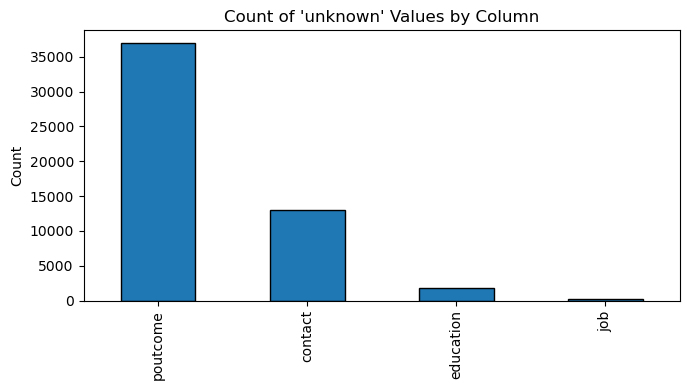

In [47]:
# check: "unknown" values in categorical columns
cols_check = df.select_dtypes(include="object").columns
unknown_val_counts = (df[cols_check] == "unknown").sum()
unknown_val_counts = unknown_val_counts[unknown_val_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(7, 4))
unknown_val_counts.plot(kind="bar", edgecolor="black")
plt.title("Count of 'unknown' Values by Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Result:** No missing values present, but some categories like job and education have "unknown" entries. These stay as a separate group since they may still help predictions.

In [48]:
# choose numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
print(numerical_columns)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


** Correlation Matrix of Numerical Features **

In [49]:
# selecting numerical features
numerical_columns = df.select_dtypes(include=["int64", "float64"])

# Calculating correlation matrix
correlation_matrix = numerical_columns.corr()

# Displaying correlation matrix
correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


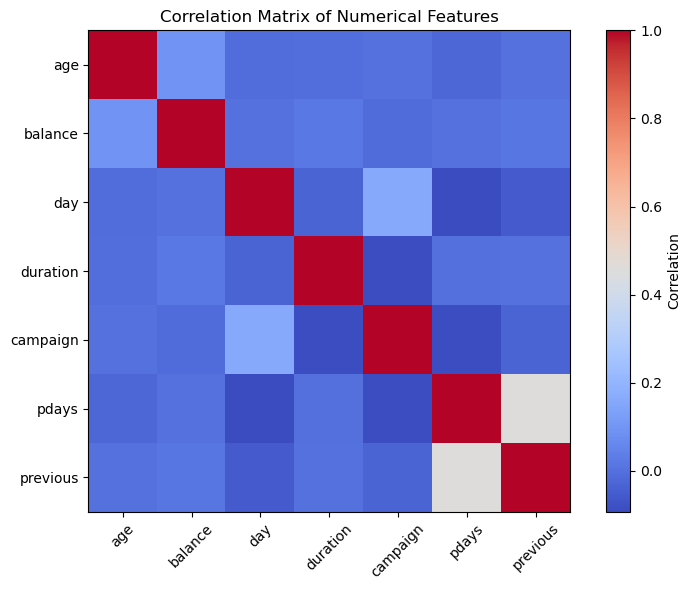

In [50]:

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

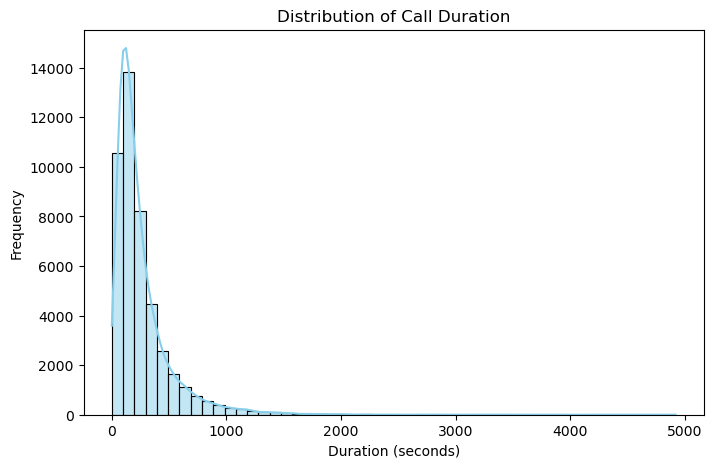

In [51]:
# Histogram
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='duration', bins=50, kde=True, color='skyblue')
plt.title('Distribution of Call Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

** Initial Findings **

    The dataset contains 45211 customer records and 17 variables.

    There are no missing (NaN) values. Still, some categories contain  "unknown" and will be handled during data preprocessing.

    No duplicated records were found.

    The target  is imbalanced. So Precision, Recall, F1-score and ROC-AUC will be used instead of relying only on accuracy.

    The correlation matrix showed that there is no serious multicollinearity problem and all numerical features can be used for model building.

    In historam, call duration characteristic is typically one of the best indicators of whether a client will sign up for a term deposit.

    Categorical variables like job, education and marital status will be converted into numerical values using OneHotEncoder before training the models.

## 5. Feature Engineering

Feature engineering focused on preparing existing features by separating data types.

In [52]:
# target distribution
X = df.drop("y", axis=1)

# Target
y = df["y"]
# Converting target to numbers
y = y.map({"no": 0, "yes": 1})

In [53]:
#  Created feature List
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical Features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [54]:
# Strategy A , without scaling

numeric_transform_A = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transform_A = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_transform_A, numeric_features),
    ("cat", categorical_transform_A, categorical_features)
])

In [55]:
# Strategy B, with scaling

# Numerical  pipeline
numeric_transform_B = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical  pipeline
categorical_transform_B = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical pipelines
preprocessor_B = ColumnTransformer([
    ("num", numeric_transform_B, numeric_features),
    ("cat", categorical_transform_B, categorical_features)
])

In [56]:

# Strategy A, logistic regression pipeline without scaling
logistic_pipeline_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])


# Strategy B, logistic regression pipeline with Scaling
logistic_pipeline_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

In [57]:

# Strategy A,  random forest without scaling
rf_pipeline_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])


# Strategy B, random Forest with Scaling
rf_pipeline_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

## 6. Data Engineering Comparison

In [58]:
# divide the dataset into training - 80 percent and testing -20 percent
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("training data:", X_train.shape)
print("testing data:", X_test.shape)

training data: (36168, 16)
testing data: (9043, 16)


In [59]:
# train for Logistic Regression - Strategy A
logistic_pipeline_A.fit(X_train, y_train)

# Train for Logistic Regression - Strategy B
logistic_pipeline_B.fit(X_train, y_train)

# Train for Random Forest - Strategy A
rf_pipeline_A.fit(X_train, y_train)

# Train for Random Forest - Strategy B
rf_pipeline_B.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [60]:
# prediction

y_pred_lr_A = logistic_pipeline_A.predict(X_test)
y_pred_lr_B = logistic_pipeline_B.predict(X_test)

y_pred_rf_A = rf_pipeline_A.predict(X_test)
y_pred_rf_B = rf_pipeline_B.predict(X_test)

In [61]:

comparison_scaling = pd.DataFrame({
    "Strategy": [
        "A - Without Scaling",
        "B - With Scaling",
        "A - Without Scaling",
        "B - With Scaling"
    ],
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest"
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr_A),
        f1_score(y_test, y_pred_lr_B),
        f1_score(y_test, y_pred_rf_A),
        f1_score(y_test, y_pred_rf_B)
    ]
})

comparison_scaling.round(4)

,Strategy,Model,F1 Score
0,A - Without Scaling,Logistic Regression,0.5420
1,B - With Scaling,Logistic Regression,0.5527
2,A - Without Scaling,Random Forest,0.4484
3,B - With Scaling,Random Forest,0.4484


<Figure size 800x500 with 0 Axes>

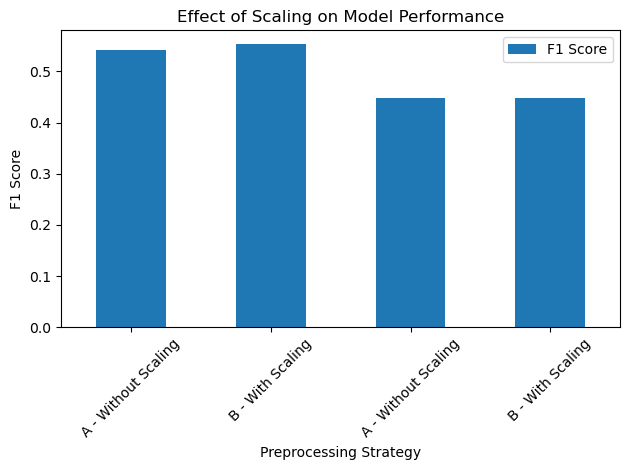

In [62]:
plt.figure(figsize=(8, 5))

comparison_scaling.plot(
    x="Strategy",
    y="F1 Score",
    kind="bar"
)

plt.title("Effect of Scaling on Model Performance")
plt.xlabel("Preprocessing Strategy")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Result:**  The F1-scores of both strategies were compared using the same training and test datasets. The results show that scaling had a positive effect on Logistic Regression, while its effect on Random Forest was minimal. 

## 7. Pipeline Construction
The pipeline combines preprocessing and model training automatically, to make sure that the consistent data handling and best methods to both models.

In [63]:
# Create the Logistic Regression Pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])
print(logistic_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                  

In [64]:
# Create the Random Forest Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                  

There are various advantages to use a pipeline:

1. Both Preprocessing and model training are added into one workflow that ensure training and testing data go through the same steps and prevent data leakage

2. It makes  the proccess easy to maintain the notebook and removes duplicate code.

3. With  help of GridSearchCV, enabling  model adjustment and preprocessing.

## 8. Hyperparameter Tuning using GridSearchCV
GridSearchCV automatically tests different hyperparameters for logistic regression and Random Forest.

### 8.1 Logistic Regression Hyperparameters
- **C**: opposite of strength. It means  smaller C = simpler model(stronger regularization).
larger c =  training data fits more closely.
- **solver**: Help to find best weight or coefficient (liblinear vs lbfgs).
- **class_weight**: declared balance to handle imbalance dataset.

### 8.2  Random Forest Hyperparameters
- **n_estimators**: It denoted tree count. Here, more trees means more stable and slower.
- **max_depth**: How  much  deep a tree can grow.
- **min_samples_split**: Minimum number of samples required to split the node firther

In [65]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
# Hyperparameter grid for Logistic Regression

param_grid_lr = {
    "model__C": [0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

In [66]:
# Create GridSearchCV for Logistic Regression
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [67]:
# Train Logistic Regression
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [68]:
# display best parameters
print("Best Parameters:")
print(grid_lr.best_params_)

# cross section validation
print("Best Cross-validation F1 score:")
print(round(grid_lr.best_score_,4))

Best Parameters:
{'model__C': 1, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}
Best Cross-validation F1 score:
0.5514


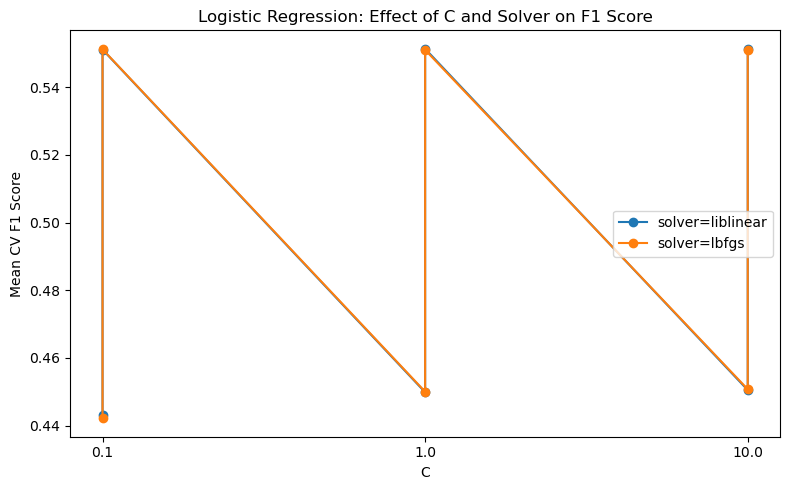

In [69]:
# Visualize LR performance across hyperparameter values
lr_results = pd.DataFrame(grid_lr.cv_results_)

plt.figure(figsize=(8, 5))
for solver in lr_results["param_model__solver"].unique():
    subset = lr_results[lr_results["param_model__solver"] == solver]
    subset = subset.sort_values("param_model__C")
    plt.plot(subset["param_model__C"].astype(str), subset["mean_test_score"],
              marker="o", label=f"solver={solver}")

plt.xlabel("C")
plt.ylabel("Mean CV F1 Score")
plt.title("Logistic Regression: Effect of C and Solver on F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# Hyperparameter Grid for Random Forest
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

In [71]:
# Create GridSearchCV for Random Forest
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [72]:
# train random set
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [73]:
# Display Best Parameters
print("Best Parameters:")
print(grid_rf.best_params_)
# display best score of cross validation
print("Best Cross-validation F1-score:")
print(round(grid_rf.best_score_,4))

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Cross-validation F1-score:
0.5908


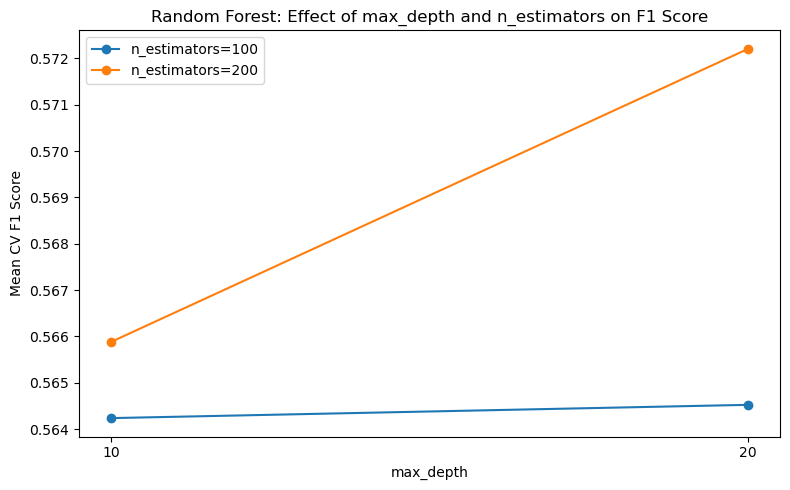

In [74]:
# Visualize RF performance across hyperparameter values
rf_results = pd.DataFrame(grid_rf.cv_results_)

pivot = rf_results.pivot_table(
    index="param_model__max_depth",
    columns="param_model__n_estimators",
    values="mean_test_score"
)

plt.figure(figsize=(8, 5))
for n_est in pivot.columns:
    plt.plot(pivot.index.astype(str), pivot[n_est], marker="o", label=f"n_estimators={n_est}")

plt.xlabel("max_depth")
plt.ylabel("Mean CV F1 Score")
plt.title("Random Forest: Effect of max_depth and n_estimators on F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

### Hyperparameter Effects
LR: F1 score becomes well when c raise from 0.1 to 1, then at  C=10 — moderate regularization works best.
RF: Performed better than max_depth at 10 when it becomes double. I.E max/-depth = 20; n_estimators=200. It gave verly less improvement  over 100 trees at double cost.

In [75]:
# Compare the Tuned Models

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Best CV F1 Score": [
        grid_lr.best_score_,
        grid_rf.best_score_
    ]
})

comparison

,Model,Best CV F1 Score
0,Logistic Regression,0.551395
1,Random Forest,0.590784


**Observation:** Random Forest performed better(0.590784) over Logistic Regression (0.551395).

## 9. Model evaluation
It checks that how  the best Logistic Regression and Random Forest models work on new data. Multiple metrics are used to handle unbalanced data.

In [76]:
# Get the best models from GridSearchCV
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

In [77]:
# Logistic Regression predictions

y_pred_lr = best_lr.predict(X_test)

# Random Forest predictions

y_pred_rf = best_rf.predict(X_test)

In [78]:
# Create comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, best_lr.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8457,0.4182,0.8147,0.5527,0.9079
1,Random Forest,0.8984,0.5584,0.6285,0.5914,0.9268


In [79]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043

Random Forest
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7985
           1       0.56      0.63      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.78      0.77      9043
weighted avg       0.90      0.90      0.90      9043



**Result:** It shows the model  predicts most customer results accurately. It balances both precision and recall and making it reliable for subscription predictions.

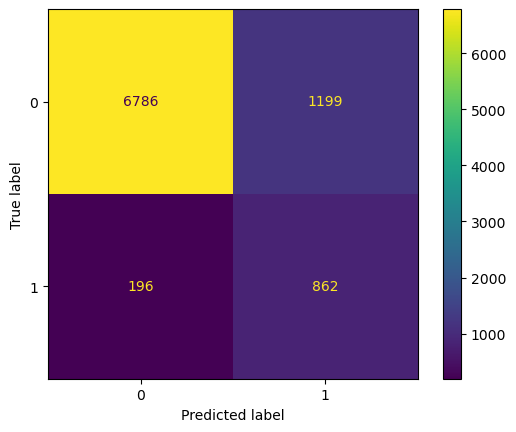

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

**Result:** It shows that most customers were correctly classified. Here, few mistakes indicates that the model gives reliable predictions and works in good way.

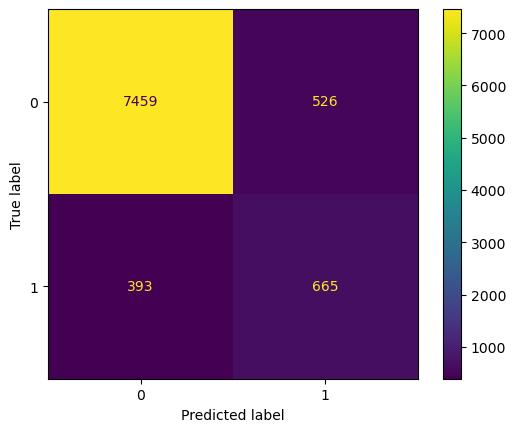

In [81]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
   
)

**Result:** It shows that many correct predictions and fewer mistakes than Logistic Regression. It handles complex patterns in better way and gives strong performance.

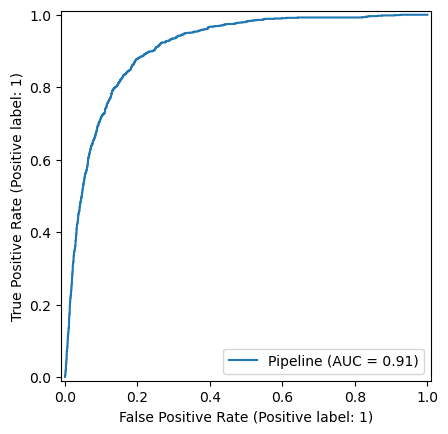

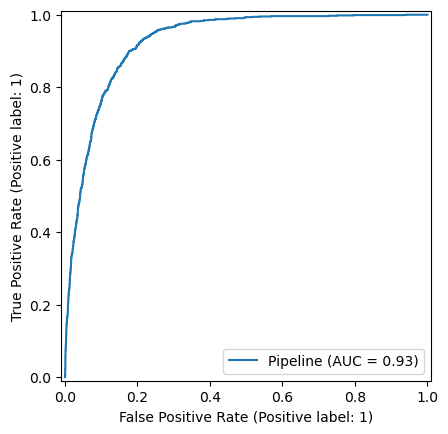

In [82]:
# ROC curv and AUC
RocCurveDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

**Result:** The ROC-AUC score shows that how a model separates customers who will subscribe or not. A higher score means better separation.
Random Forest scored higher value  than Logistic Regression.

In [83]:
#  Feature Importance (Random Forest Only)
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

importance = best_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,num__duration,0.378196
1,num__balance,0.059952
0,num__age,0.058470
2,num__day,0.053706
49,cat__poutcome_success,0.037946
5,num__pdays,0.033317
34,cat__contact_unknown,0.029727
4,num__campaign,0.027926
6,num__previous,0.020998
29,cat__housing_yes,0.020045


**Result:** Features that score higher value in importance have more influence in decision-making process.

# 10. Final Discussion
**10.1 Strengths and Limitations**

**Strengths**
The solution involves pipelines, cross validation, hyperparameter tuning and multiple evaluation metrics. The comparison between Logistic Regression and Random Forest gives better choice of model and the feature importance helps in better interpretation of the model.

**Limitations**
The model used historical data, which might not work on new data. Random Forest is hard to explain that others model, but the F1-score being moderate might still make some errors. Before deploymenT, optimization and external validation is required

**10.2 Business implications of results**
The F1-Score of random forest model approximately 0.59 and ROC-AUC of 0.93, indicating good performance. From these predictions, banck can  prioritise interested customers, improving campaign efficiency and reduced unnecessary contacts.

**10.3 Deployment Decision**
As a decision-support tool, this model can be used for targeted marketing. Before full-scale deployment, it is important to validate performance.

**10.4 Data-Driven Recommendations**
The bank should Priortiza customers that are recommended by model to subscribe.
Keep checking model performance by  checking F1-score, precision and recall and retrain it from time to time with the latest campaign data so it gives good accuracy.


## 11. Conclusion: 

I created a model to predict if bank customers will take  plan of term deposit. The target was imbalanced, so I used precision, recall and F1-score.

I compared Logistic Regression (85% accuracy, high recall) and Random Forest (90% accuracy, better F1-score of 0.59). Random Forest model performace is good.

Therefore Random forest model can helplot to target the customers.

## 12. References

Moro, S., Rita, P. and Cortez, P. (2014) *Bank Marketing* [dataset]. UCI Machine Learning Repository. Available at: https://archive.ics.uci.edu/ml/datasets/bank+marketing (Accessed: 21 August 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830. Available at: https://scikit-learn.org (Accessed: 21 August 2026).

scikit-learn developers (n.d.) *scikit-learn documentation*. Available at: https://scikit-learn.org/stable/ (Accessed: 21 August 2026).